# Fraud Detection — Model Training & Evaluation

## Business Context

The goal is not to build the most accurate classifier — it is to build a classifier whose **error profile is acceptable to the business**.

In financial crime prevention, the two error types have very different costs:

- **False Negative (missed fraud):** The bank absorbs the loss, the cardholder is harmed, and repeated misses attract regulatory scrutiny. This is typically the more expensive error.
- **False Positive (blocked legitimate customer):** Customer friction, potential churn, and call-centre costs. At scale, even a small false-positive rate affects millions of transactions.

The **decision threshold** — the probability above which we classify a transaction as fraud — is a business decision, not a statistical one. Lowering it catches more fraud but blocks more legitimate customers. This notebook makes that trade-off explicit.

### Approach
1. Baseline: Logistic Regression (interpretable, fast, good benchmark)
2. Random Forest (captures non-linear patterns, robust to outliers)
3. XGBoost (state-of-the-art gradient boosting, typically best performance)
4. All models evaluated on Precision-Recall AUC and F1 at business-relevant thresholds
5. SMOTE applied to address class imbalance in training data

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve,
    average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
FRAUD_COLOR, LEGIT_COLOR = '#e74c3c', '#2ecc71'

DB_PATH = Path('../data/fraud_detection.db')
MODELS_PATH = Path('../models')
MODELS_PATH.mkdir(exist_ok=True)

conn = sqlite3.connect(DB_PATH)
print('Connected to', DB_PATH)


Connected to ..\data\fraud_detection.db


## 1. Load & Prepare Data

We load all transactions from the database and sort by `Time` so validation simulates scoring future transactions. `Time` is retained only for splitting and reporting the chronological ranges; it is not used as a model feature. `Amount` is log-transformed to reduce the influence of extreme values.


In [2]:
df = pd.read_sql_query("""
    SELECT
        Time,
        V1, V2, V3, V4, V5, V6, V7, V8, V9, V10,
        V11, V12, V13, V14, V15, V16, V17, V18, V19, V20,
        V21, V22, V23, V24, V25, V26, V27, V28,
        Amount,
        is_fraud
    FROM transactions
    ORDER BY Time
""", conn)

# Log-transform Amount (add 1 to handle zero-value transactions)
df['Amount_log'] = np.log1p(df['Amount'])
df = df.drop(columns=['Amount'])

FEATURE_COLS = [c for c in df.columns if c not in ['is_fraud', 'Time']]
X = df[FEATURE_COLS]
y = df['is_fraud']

print(f'Features : {len(FEATURE_COLS)}')
print(f'Total samples : {len(df):,}')
print(f'Fraud cases : {y.sum():,} ({y.mean()*100:.3f}%)')
print(f'Time range : {df["Time"].min():.0f} to {df["Time"].max():.0f} seconds')


Features : 29
Total samples : 284,807
Fraud cases : 492 (0.173%)
Time range : 0 to 172792 seconds


## 2. Chronological Train / Validation / Test Split

Fraud models should be evaluated on future transactions, not a random sample from the same time period. We therefore split the dataset chronologically: the first 60% is used for training, the next 20% for model selection and threshold tuning, and the final 20% is held back as the untouched test set.

This is more realistic than a random stratified split, but it can produce different fraud rates in each split because fraud activity is clustered over time. That variance is part of the point: the final test set should represent a future period the model has not influenced.


In [3]:
n_samples = len(df)
train_end = int(n_samples * 0.60)
val_end   = int(n_samples * 0.80)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

def describe_split(name, start, end, target):
    split_df = df.iloc[start:end]
    print(
        f'{name:<10}: {len(split_df):>7,} samples | '
        f'{target.sum():>3,} fraud ({target.mean()*100:.3f}%) | '
        f'Time {split_df["Time"].min():.0f} to {split_df["Time"].max():.0f}'
    )

print('Chronological split:')
describe_split('Train', 0, train_end, y_train)
describe_split('Validation', train_end, val_end, y_val)
describe_split('Test', val_end, n_samples, y_test)

# Scale features using training data only.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


Chronological split:
Train     : 170,884 samples | 360 fraud (0.211%) | Time 0 to 120396
Validation:  56,961 samples |  57 fraud (0.100%) | Time 120396 to 145247
Test      :  56,962 samples |  75 fraud (0.132%) | Time 145248 to 172792


## 3. Handling Class Imbalance with SMOTE

SMOTE is applied to the training split only. Validation and test keep their natural fraud prevalence so model selection and final evaluation reflect future data rather than synthetic samples.


In [4]:
smote = SMOTE(random_state=42, sampling_strategy=0.1)  # 1 fraud per 10 legit in training
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('After SMOTE:')
print(f'  Train size : {len(X_train_smote):,}')
print(f'  Fraud cases: {y_train_smote.sum():,} ({y_train_smote.mean()*100:.1f}%)')
print(f'  Legit cases: {(y_train_smote==0).sum():,}')

After SMOTE:
  Train size : 187,576
  Fraud cases: 17,052 (9.1%)
  Legit cases: 170,524


## 4. Model Training

### 4a. Logistic Regression — Interpretable Baseline

Logistic Regression is a useful baseline because it is fast, stable, and easier to inspect than tree ensembles. In this project it is treated as a benchmark, not as evidence of regulatory readiness.


In [5]:
lr = LogisticRegression(max_iter=1000, random_state=42, C=0.1)
lr.fit(X_train_smote, y_train_smote)

lr_val_proba = lr.predict_proba(X_val_scaled)[:, 1]
print('Logistic Regression trained.')
print(f'Validation PR-AUC: {average_precision_score(y_val, lr_val_proba):.4f}')
print(f'Validation ROC-AUC: {roc_auc_score(y_val, lr_val_proba):.4f}')


Logistic Regression trained.
Validation PR-AUC: 0.7080
Validation ROC-AUC: 0.9630


### 4b. Random Forest — Non-Linear Patterns

Random Forest captures complex, non-linear relationships between features — for example, a fraudulent pattern might only emerge when V14 is negative **and** Amount is below £20. It is also naturally robust to the scale of input features.

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_smote, y_train_smote)

rf_val_proba = rf.predict_proba(X_val_scaled)[:, 1]
print('Random Forest trained.')
print(f'Validation PR-AUC: {average_precision_score(y_val, rf_val_proba):.4f}')
print(f'Validation ROC-AUC: {roc_auc_score(y_val, rf_val_proba):.4f}')


Random Forest trained.
Validation PR-AUC: 0.7438
Validation ROC-AUC: 0.9709


### 4c. XGBoost — Gradient Boosting

XGBoost sequentially builds trees where each tree corrects the errors of the previous ensemble. The `scale_pos_weight` parameter directly encodes the imbalance ratio, telling the model to penalise missing fraud cases more heavily than misclassifying legitimate transactions.

In [7]:
# scale_pos_weight = ratio of negatives to positives in training data
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight = {spw:.1f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_scaled, y_train, verbose=False)

xgb_val_proba = xgb.predict_proba(X_val_scaled)[:, 1]
print('XGBoost trained.')
print(f'Validation PR-AUC: {average_precision_score(y_val, xgb_val_proba):.4f}')
print(f'Validation ROC-AUC: {roc_auc_score(y_val, xgb_val_proba):.4f}')


scale_pos_weight = 473.7


XGBoost trained.
Validation PR-AUC: 0.7881
Validation ROC-AUC: 0.9778


## 5. Model Comparison on Validation Data

The validation split is used for model comparison and threshold selection. The test split remains untouched until the final evaluation after all choices are fixed.


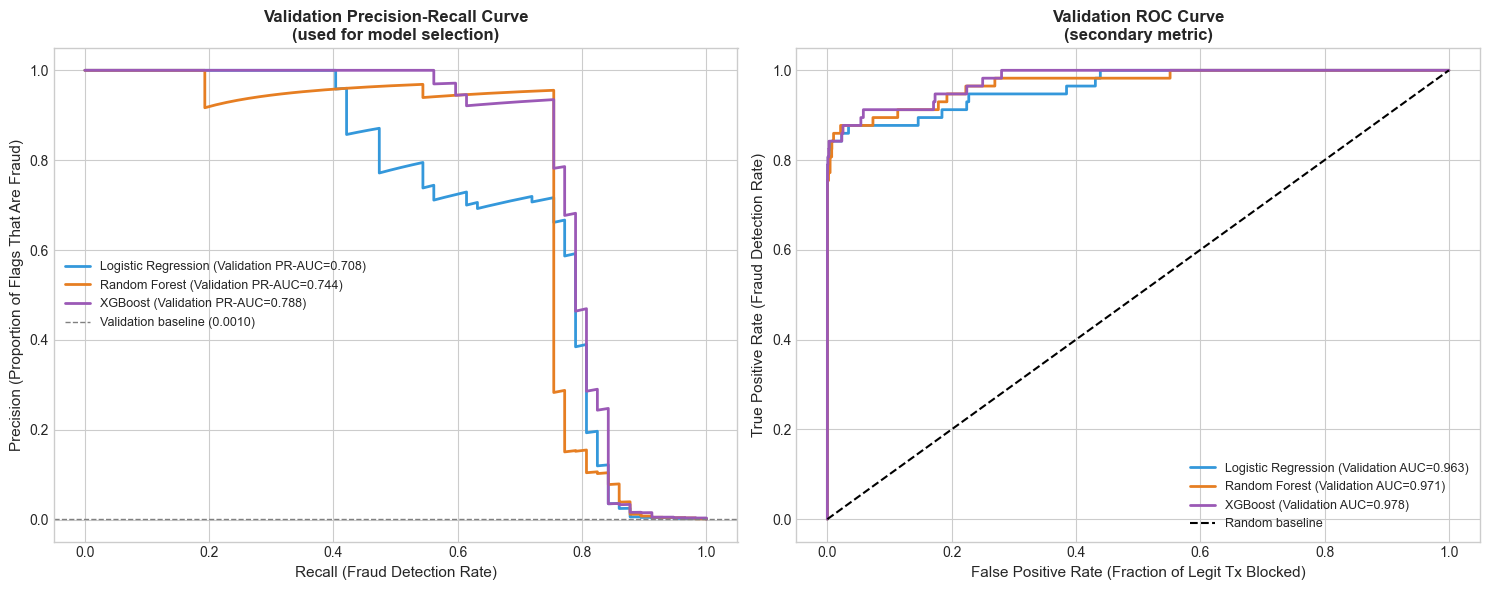

In [8]:
val_models = {
    'Logistic Regression': lr_val_proba,
    'Random Forest':       rf_val_proba,
    'XGBoost':             xgb_val_proba,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = ['#3498db', '#e67e22', '#9b59b6']

for (name, proba), color in zip(val_models.items(), colors):
    ap = average_precision_score(y_val, proba)
    p, r, _ = precision_recall_curve(y_val, proba)
    axes[0].plot(r, p, label=f'{name} (Validation PR-AUC={ap:.3f})', color=color, linewidth=2)

axes[0].axhline(y_val.mean(), linestyle='--', color='grey', linewidth=1,
                label=f'Validation baseline ({y_val.mean():.4f})')
axes[0].set_xlabel('Recall (Fraud Detection Rate)', fontsize=11)
axes[0].set_ylabel('Precision (Proportion of Flags That Are Fraud)', fontsize=11)
axes[0].set_title('Validation Precision-Recall Curve\n(used for model selection)',
                  fontweight='bold')
axes[0].legend(fontsize=9)

for (name, proba), color in zip(val_models.items(), colors):
    auc = roc_auc_score(y_val, proba)
    fpr, tpr, _ = roc_curve(y_val, proba)
    axes[1].plot(fpr, tpr, label=f'{name} (Validation AUC={auc:.3f})', color=color, linewidth=2)
axes[1].plot([0,1],[0,1], 'k--', label='Random baseline')
axes[1].set_xlabel('False Positive Rate (Fraction of Legit Tx Blocked)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Fraud Detection Rate)', fontsize=11)
axes[1].set_title('Validation ROC Curve\n(secondary metric)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 6. Decision Threshold Tuning on Validation Data

The threshold is selected on validation data only. Once selected, it is frozen and used unchanged for the final test-set evaluation.


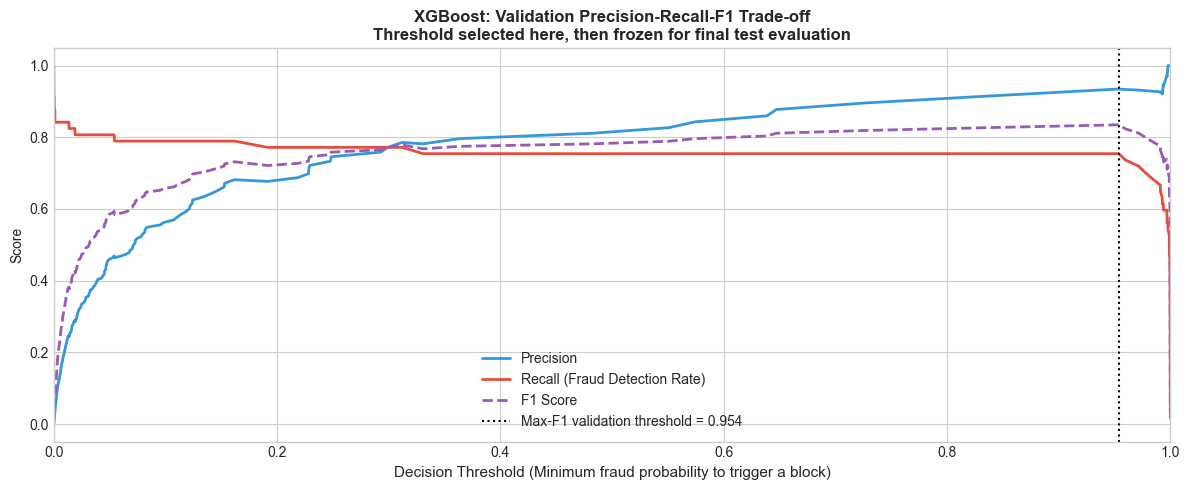

Validation PR-AUC scores:
  XGBoost               : 0.7881 <-- SELECTED
  Random Forest         : 0.7438
  Logistic Regression   : 0.7080

Selected model: XGBoost
Validation threshold (max F1): 0.9537
  Validation precision: 0.9348
  Validation recall   : 0.7544
  Validation F1       : 0.8350


In [9]:
# Select the model with the highest validation PR-AUC.
model_objects = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'XGBoost':             xgb,
}
val_pr_aucs = {name: average_precision_score(y_val, proba)
               for name, proba in val_models.items()}

best_model_name = max(val_pr_aucs, key=val_pr_aucs.get)
best_model      = model_objects[best_model_name]
best_val_proba  = val_models[best_model_name]

precisions, recalls, thresholds = precision_recall_curve(y_val, best_val_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Threshold at max validation F1.
best_f1_idx = np.argmax(f1_scores[:-1])
best_thresh = thresholds[best_f1_idx]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, precisions[:-1], color='#3498db', label='Precision', linewidth=2)
ax.plot(thresholds, recalls[:-1],    color=FRAUD_COLOR, label='Recall (Fraud Detection Rate)', linewidth=2)
ax.plot(thresholds, f1_scores[:-1],  color='#9b59b6', label='F1 Score', linewidth=2, linestyle='--')
ax.axvline(best_thresh, color='black', linestyle=':', linewidth=1.5,
           label=f'Max-F1 validation threshold = {best_thresh:.3f}')
ax.set_xlabel('Decision Threshold (Minimum fraud probability to trigger a block)', fontsize=11)
ax.set_ylabel('Score')
ax.set_title(f'{best_model_name}: Validation Precision-Recall-F1 Trade-off\n'
             'Threshold selected here, then frozen for final test evaluation',
             fontweight='bold')
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print('Validation PR-AUC scores:')
for name, score in sorted(val_pr_aucs.items(), key=lambda x: -x[1]):
    marker = ' <-- SELECTED' if name == best_model_name else ''
    print(f'  {name:<22}: {score:.4f}{marker}')
print()
print(f'Selected model: {best_model_name}')
print(f'Validation threshold (max F1): {best_thresh:.4f}')
print(f'  Validation precision: {precisions[best_f1_idx]:.4f}')
print(f'  Validation recall   : {recalls[best_f1_idx]:.4f}')
print(f'  Validation F1       : {f1_scores[best_f1_idx]:.4f}')


In [10]:
# Business cost analysis on validation data only.
FRAUD_COST   = 200   # Average cost of a missed fraud (£)
FP_COST      =   5   # Cost of blocking a legitimate customer (£)

cost_rows = []
for thresh in sorted(set([0.1, 0.2, 0.3, 0.4, 0.5, float(best_thresh), 0.7, 0.9])):
    preds = (best_val_proba >= thresh).astype(int)
    cm = confusion_matrix(y_val, preds)
    tn, fp, fn, tp = cm.ravel()
    total_cost = fn * FRAUD_COST + fp * FP_COST
    cost_rows.append({
        'Threshold': round(thresh, 3),
        'Fraud Caught (TP)': tp,
        'Fraud Missed (FN)': fn,
        'Legit Blocked (FP)': fp,
        'Recall': round(tp / (tp + fn), 3),
        'Precision': round(tp / (tp + fp + 1e-9), 3),
        'Est. Cost (£)': f'{total_cost:,.0f}'
    })

cost_df = pd.DataFrame(cost_rows)
print(f'Validation cost model: £{FRAUD_COST} per missed fraud | £{FP_COST} per blocked legitimate customer')
print()
print(cost_df.to_string(index=False))


Validation cost model: £200 per missed fraud | £5 per blocked legitimate customer

 Threshold  Fraud Caught (TP)  Fraud Missed (FN)  Legit Blocked (FP)  Recall  Precision Est. Cost (£)
     0.100                 45                 12                  34   0.789      0.570         2,570
     0.200                 44                 13                  20   0.772      0.687         2,700
     0.300                 44                 13                  12   0.772      0.786         2,660
     0.400                 43                 14                  10   0.754      0.811         2,850
     0.500                 43                 14                   9   0.754      0.827         2,845
     0.700                 43                 14                   5   0.754      0.896         2,825
     0.900                 43                 14                   3   0.754      0.935         2,815
     0.954                 43                 14                   3   0.754      0.935         2,815

## 7. Validation Confusion Matrices

These matrices show each model at its own max-F1 validation threshold. They support model comparison only; final performance is reported separately on the untouched test split.


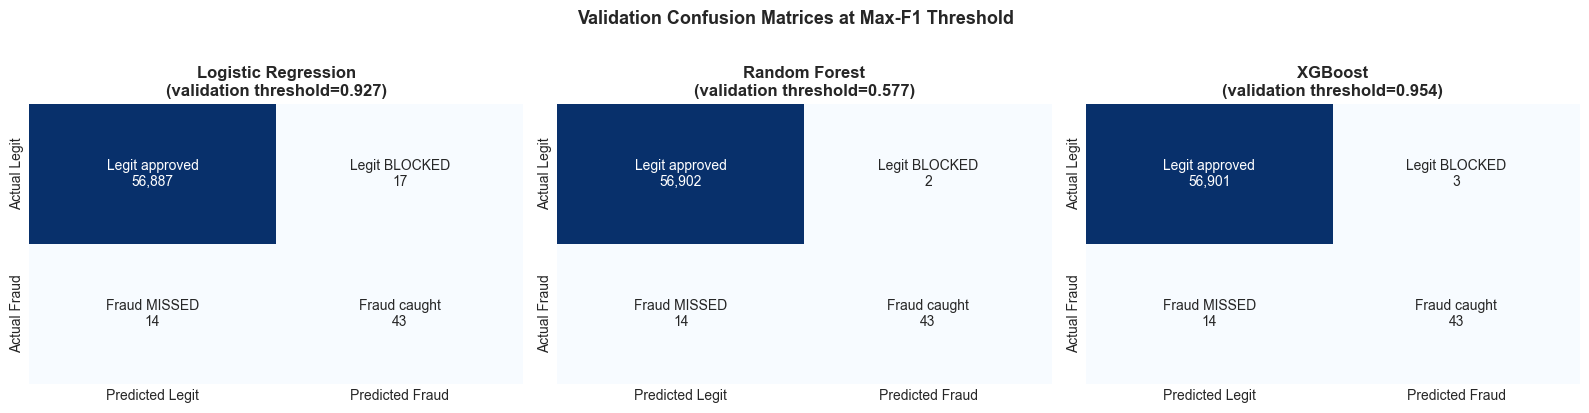

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, proba) in zip(axes, val_models.items()):
    p_vals, r_vals, threshs = precision_recall_curve(y_val, proba)
    f1s = 2 * (p_vals * r_vals) / (p_vals + r_vals + 1e-9)
    thresh = threshs[np.argmax(f1s[:-1])] if len(threshs) else 0.5

    preds = (proba >= thresh).astype(int)
    cm = confusion_matrix(y_val, preds)

    labels = np.array([
        [f'Legit approved\n{cm[0,0]:,}',  f'Legit BLOCKED\n{cm[0,1]:,}'],
        [f'Fraud MISSED\n{cm[1,0]:,}',    f'Fraud caught\n{cm[1,1]:,}']
    ])

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'])
    ax.set_title(f'{name}\n(validation threshold={thresh:.3f})', fontweight='bold')

plt.suptitle('Validation Confusion Matrices at Max-F1 Threshold', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 8. Final Test Evaluation

The test split is evaluated once, after the model and threshold have already been selected on validation data.


In [12]:
# Score the untouched test set only after all model-selection decisions are fixed.
test_proba = best_model.predict_proba(X_test_scaled)[:, 1]
test_preds = (test_proba >= best_thresh).astype(int)

print(f'=== Final Test: {best_model_name} (frozen threshold={best_thresh:.3f}) ===')
print(classification_report(y_test, test_preds,
                             target_names=['Legitimate', 'Fraud']))
print(f'Test PR-AUC : {average_precision_score(y_test, test_proba):.4f}')
print(f'Test ROC-AUC: {roc_auc_score(y_test, test_proba):.4f}')

cm = confusion_matrix(y_test, test_preds)
tn, fp, fn, tp = cm.ravel()
print()
print('Final test confusion matrix:')
print(f'  Legit approved : {tn:,}')
print(f'  Legit blocked  : {fp:,}')
print(f'  Fraud missed   : {fn:,}')
print(f'  Fraud caught   : {tp:,}')
print(f'  Test cost estimate: £{fn * FRAUD_COST + fp * FP_COST:,.0f}')


=== Final Test: XGBoost (frozen threshold=0.954) ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56887
       Fraud       0.92      0.73      0.81        75

    accuracy                           1.00     56962
   macro avg       0.96      0.87      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Test PR-AUC : 0.7967
Test ROC-AUC: 0.9743

Final test confusion matrix:
  Legit approved : 56,882
  Legit blocked  : 5
  Fraud missed   : 20
  Fraud caught   : 55
  Test cost estimate: £4,025


## 9. Save Selected Model


In [13]:
joblib.dump(best_model, MODELS_PATH / 'best_model.pkl')
joblib.dump(scaler,     MODELS_PATH / 'scaler.pkl')
joblib.dump({'model_name': best_model_name, 'threshold': float(best_thresh)},
            MODELS_PATH / 'model_metadata.pkl')

print(f'Saved {best_model_name} to models/best_model.pkl')
print(f'Saved frozen threshold {best_thresh:.4f} to models/model_metadata.pkl')


Saved XGBoost to models/best_model.pkl
Saved frozen threshold 0.9537 to models/model_metadata.pkl


## 10. Modelling Summary

| Step | Purpose |
|---|---|
| Chronological train split | Fit preprocessing and model parameters on the earliest transactions |
| Chronological validation split | Select the model and tune the decision threshold without touching test data |
| Chronological test split | Estimate final performance on later, unseen transactions |

**Key decisions made:**
- SMOTE on training data only prevents synthetic examples from entering validation or test.
- Model selection and threshold tuning use validation data only.
- Final test metrics are reported once with the selected model and frozen threshold.
- PR-AUC remains the primary ranking metric because fraud is rare.
- Results may be less flattering than a random split, but they are more realistic for fraud detection.

**Next step:** Proceed to `03_explainability.ipynb` for SHAP-based model interpretation with honest handling of anonymized PCA features.


In [14]:
conn.close()